In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Dataset Structure

Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Dataset Shape

In [5]:
df.shape

(8807, 12)

Column Names

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# Check Missing Values

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Summary Statistics

In [8]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


# Data Cleaning

Remove duplicates

In [11]:
df.drop_duplicates(inplace=True)

Fill Missing Values

In [12]:
df['country'].fillna("Unknown", inplace=True)

df['director'].fillna("Not Available", inplace=True)

# Correlation Analysis

Select Numerical Columns

In [14]:
numeric_df = df.select_dtypes(include=['int64','float64'])

Correlation Matrix

In [15]:
corr = numeric_df.corr()
corr

,release_year
release_year,1.0


Heatmap Visualization

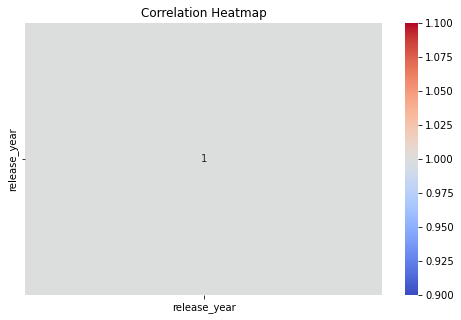

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Trend Identification

Trend 1 — Movies vs TV Shows

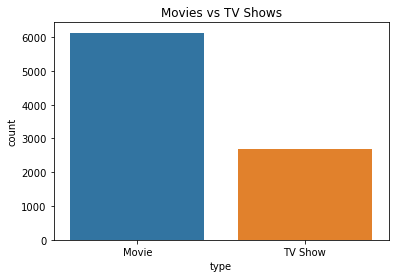

In [19]:
sns.countplot(x='type',data=df)

plt.title("Movies vs TV Shows")
plt.show()

Trend 2 — Releases by Year

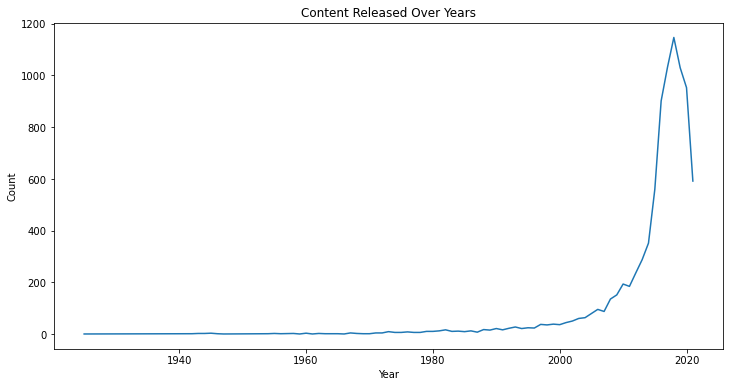

In [20]:
plt.figure(figsize=(12,6))

df['release_year'].value_counts()\
.sort_index()\
.plot()

plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

Trend 3 — Top 10 Countries

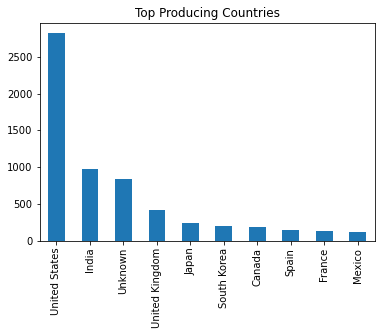

In [21]:
top_country = df['country'].value_counts().head(10)

top_country.plot(kind='bar')

plt.title("Top Producing Countries")

plt.show()

Trend 4 — Content Ratings

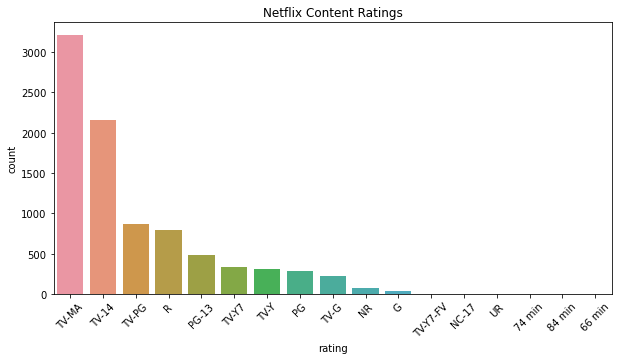

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
x='rating',
data=df,
order=df['rating'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Netflix Content Ratings")

plt.show()

Trend 5 — Monthly Additions

In [23]:
df['date_added']=pd.to_datetime(
df['date_added']
)

df['month_added']=df['date_added'].dt.month

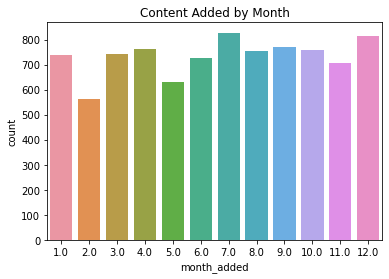

In [24]:
sns.countplot(
x='month_added',
data=df
)

plt.title("Content Added by Month")

plt.show()

# Histogram

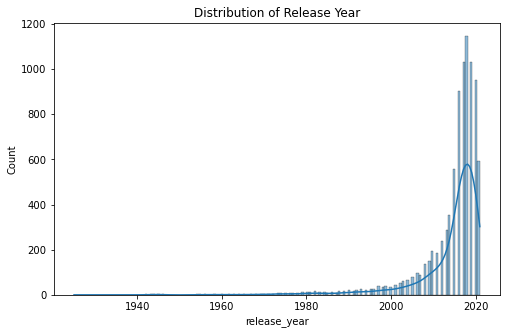

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['release_year'],
kde=True)

plt.title("Distribution of Release Year")

plt.show()

# Pie Chart

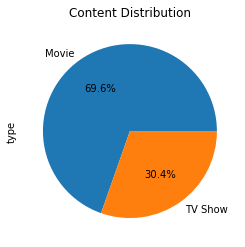

In [26]:
df['type'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.title("Content Distribution")

plt.show()

# Insights

Netflix hosts more Movies than TV Shows.

Content production increased sharply after 2015.

USA produces maximum Netflix content.

TV-MA rating dominates the platform.

# CONCLUSION

The Netflix dataset EDA revealed major content trends.
Movies dominate the platform.
Content production rapidly increased after 2015.
USA contributes most content.
TV-MA is the most frequent rating.
Correlation analysis helped understand relationships between numerical features.